In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE, ADASYN

In [2]:
DATA_DIR = '../data/raw/raw_data.csv'
df = pd.read_csv(DATA_DIR)

# Imbalance Analysis and Mitigation

In this section, we analyze the class imbalance present in the dataset and we provide different approaches to mitigate it. Among these different techniques, we find SMOTE, ADASYN, Oversampling and Subsampling. After handling imbalance we will save each of the resulting balanced datasets to later train and test our models.

## Visualization of the Imbalance

In the graphic bellow we observe the class imbalance previously discussed in the EDA. We clearly see that there are 2 majority classes that dominate over the other 5.

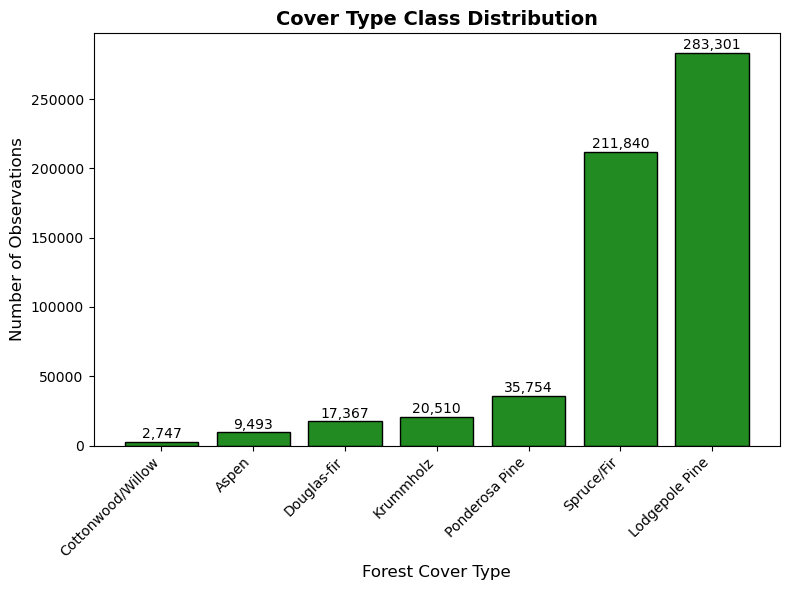

In [3]:
# Covertype Mapping
covertype_class = {
        1: 'Spruce/Fir', 2: 'Lodgepole Pine',
        3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
        5: 'Aspen', 6: 'Douglas-fir', 7:'Krummholz'
}

df['class_name'] = df['Cover_Type'].map(covertype_class)

class_counts = df['class_name'].value_counts().sort_values(ascending=True)
# Create bar chart
plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values, color='forestgreen', edgecolor='black')

for i, (name, count) in enumerate(zip(class_counts.index, class_counts.values)):
        plt.text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.title('Cover Type Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Forest Cover Type', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Mitigation Approaches
* *Oversampling*: This approach consists on generating syntehtic data from the already existing one.
    * *SMOTE*
    * *ADASYN*
* *Undersampling*: This approach consists on removing data from the majority classes. The samples removed depend on the approach followed.
    * Controlled Under-sampling
        * *Random Undersampling*
        * *NearMiss*
    * Cleaning Under-sampling
        * *Tomek's Links*
        * *Edited Nearest Neighbors*

### OVERSAMPLING

#### SMOTE

In [5]:
from collections import Counter
X = df.drop(columns=['Cover_Type', 'class_name'], axis=1)
y = df['Cover_Type']

print(f"Shape of the dataset: {Counter(y)}")

Shape of the dataset: Counter({2: 283301, 1: 211840, 3: 35754, 7: 20510, 6: 17367, 5: 9493, 4: 2747})


In [5]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(X,y)
print(f"Shape of the dataset after SMOTE: {Counter(y_resampled)}")

Shape of the dataset after SMOTE: Counter({5: 283301, 2: 283301, 1: 283301, 7: 283301, 3: 283301, 6: 283301, 4: 283301})


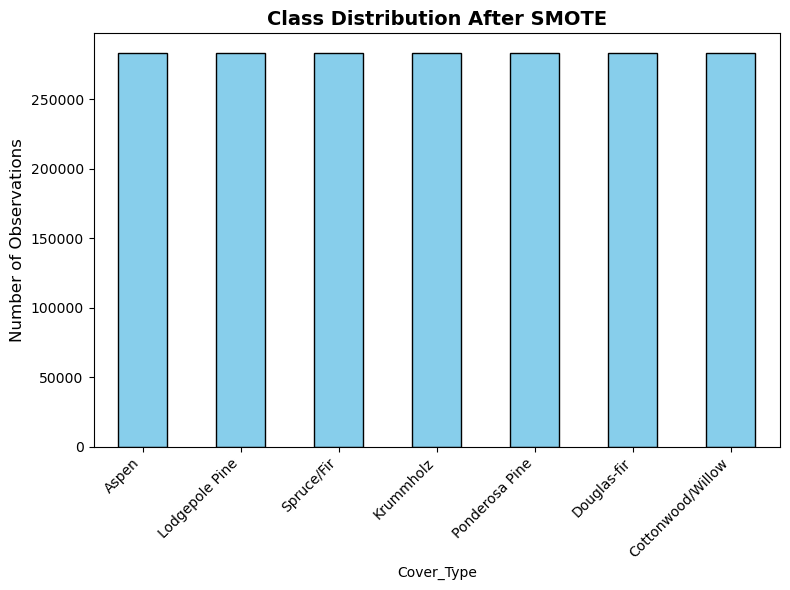

In [27]:
resampled_counts = pd.Series(y_resampled).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
resampled_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution After SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_resampled = pd.DataFrame(x_resampled, columns=X.columns)
df_resampled['Cover_Type'] = y_resampled

df_resampled.to_parquet('../data/processed/smote_balanced.parquet', index=False)

#### ADASYN

In [7]:
adasyn = ADASYN(random_state=42)
x_adasyn, y_adasyn = adasyn.fit_resample(X,y)
print(f"Shape of the dataset after ADASYN: {Counter(y_adasyn)}")

Shape of the dataset after ADASYN: Counter({5: 283537, 2: 283301, 4: 283284, 7: 282662, 6: 282644, 3: 282268, 1: 277125})


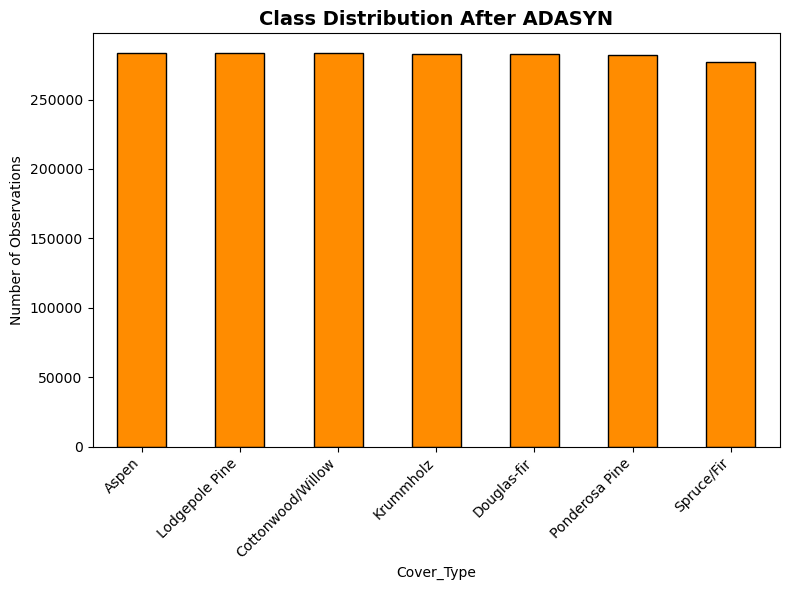

In [8]:
adasyn_counts = pd.Series(y_adasyn).map(covertype_class).value_counts()
plt.figure(figsize=(8, 6))
adasyn_counts.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Class Distribution After ADASYN', fontsize=14, fontweight='bold')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df_resampled = pd.DataFrame(x_adasyn, columns=X.columns)
df_resampled['Cover_Type'] = y_adasyn

df_resampled.to_parquet('../data/processed/adasyn_balanced.parquet', index=False)

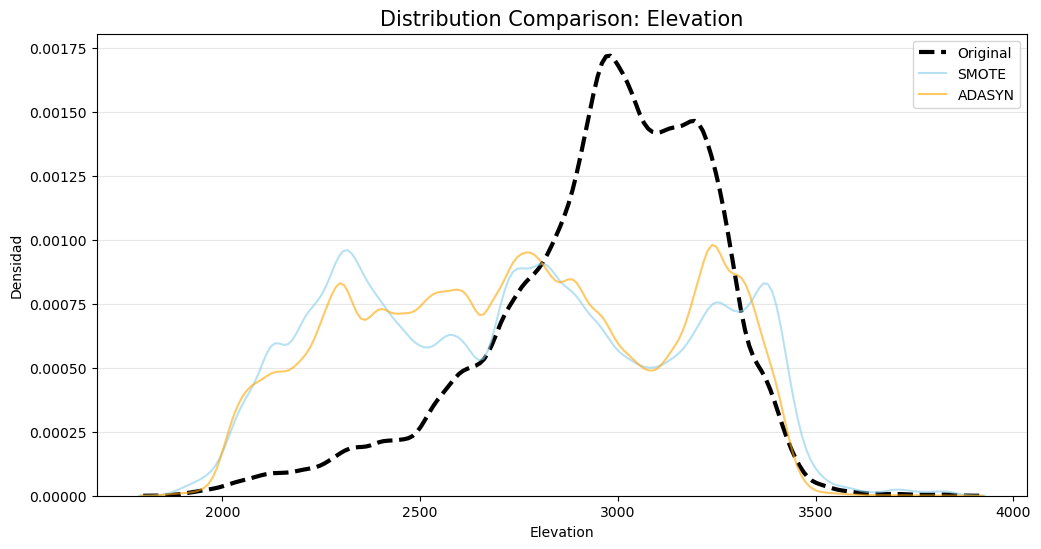

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

df_smote = pd.read_parquet('../data/processed/smote_balanced.parquet')
df_adasyn = pd.read_parquet('../data/processed/adasyn_balanced.parquet')

def plot_distribution_comparison(df_orig, df_smote, df_adasyn, feature='Elevation'):
    plt.figure(figsize=(12, 6))
    
    sns.kdeplot(df_orig[feature], label='Original', color='black', linewidth=3, linestyle='--')
    sns.kdeplot(df_smote[feature], label='SMOTE', color='skyblue', alpha=0.6)
    sns.kdeplot(df_adasyn[feature], label='ADASYN', color='orange', alpha=0.6)
    
    plt.title(f'Distribution Comparison: {feature}', fontsize=15)
    plt.xlabel(feature)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_distribution_comparison(df, df_smote, df_adasyn, feature='Elevation')

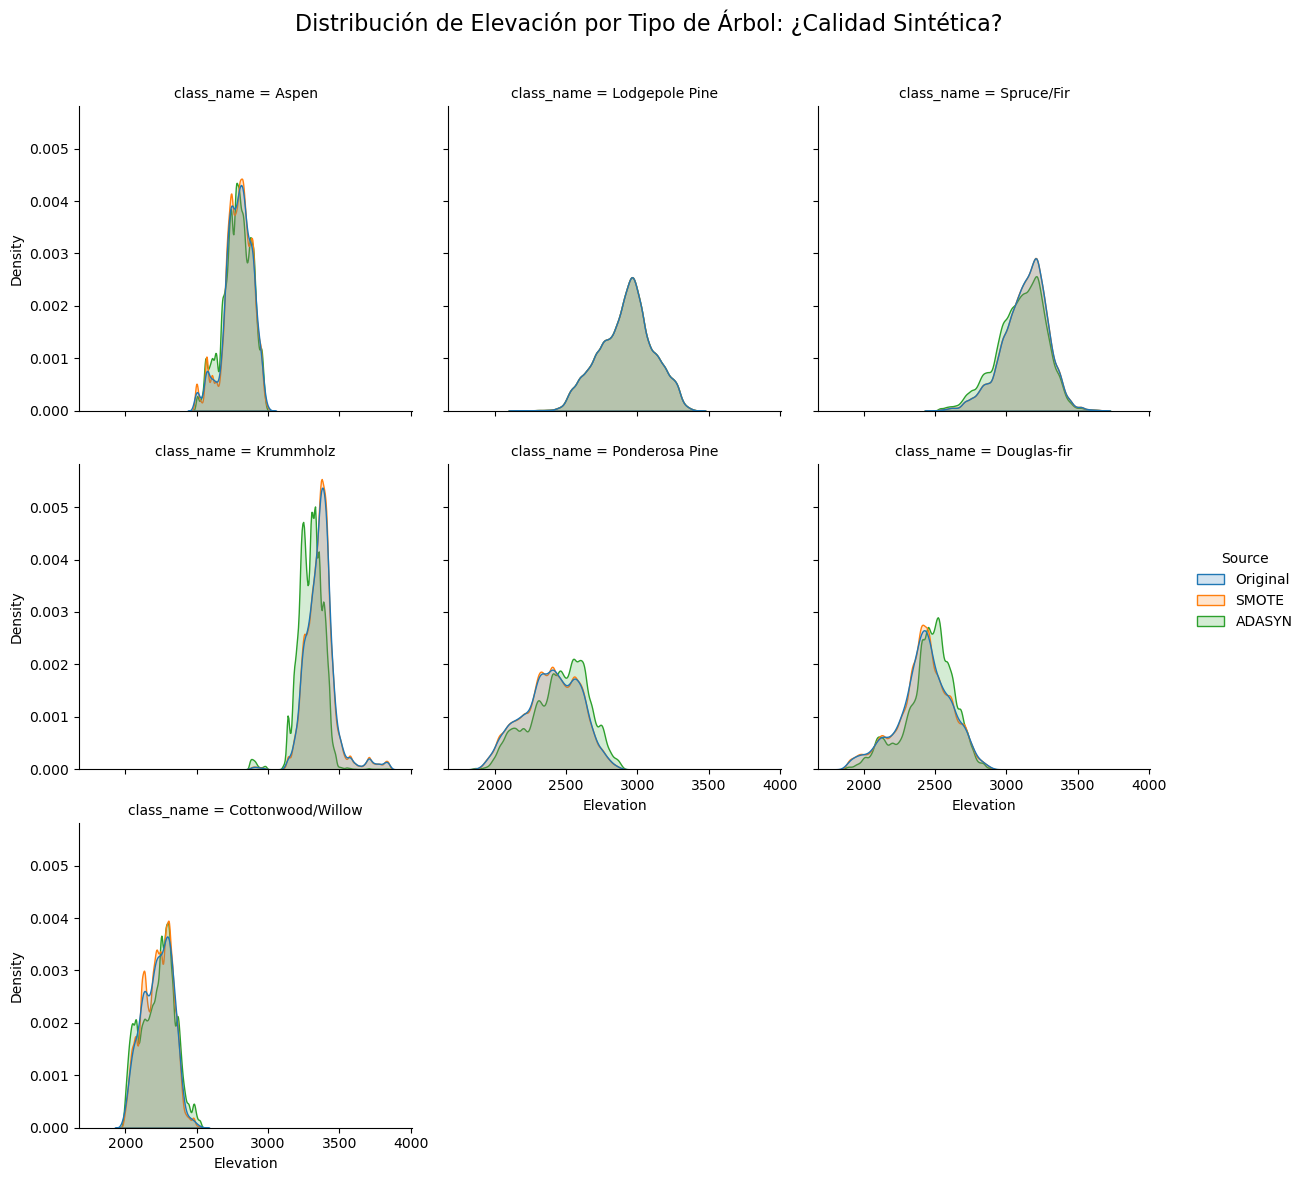

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Asegúrate de tener los DataFrames listos con sus etiquetas
df_orig_plot = df.copy()
df_orig_plot['Source'] = 'Original'

# Convertimos los arrays de salida de SMOTE/ADASYN a DataFrames
# Nota: Asegúrate de añadir las columnas que tenías originalmente
df_smote_plot = pd.DataFrame(x_resampled, columns=X.columns)
df_smote_plot['Cover_Type'] = y_resampled
df_smote_plot['class_name'] = df_smote_plot['Cover_Type'].map(covertype_class)
df_smote_plot['Source'] = 'SMOTE'

df_adasyn_plot = pd.DataFrame(x_adasyn, columns=X.columns)
df_adasyn_plot['Cover_Type'] = y_adasyn
df_adasyn_plot['class_name'] = df_adasyn_plot['Cover_Type'].map(covertype_class)
df_adasyn_plot['Source'] = 'ADASYN'

# 2. Combinamos todo
combined_df = pd.concat([df_orig_plot, df_smote_plot, df_adasyn_plot], axis=0)

# 3. Plot de comparación (FacetGrid)
g = sns.displot(
    data=combined_df, 
    x='Elevation', 
    hue='Source', 
    col='class_name', 
    kind='kde', 
    col_wrap=3,      # 3 gráficos por fila
    height=4, 
    fill=True, 
    alpha=0.2,
    common_norm=False
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Value Distribution for each Forest Type', fontsize=16)
plt.show()

### UNDERSAMPLING

##### 1. Controlled Under-sampling

#### RANDOM UNDERSAMPLING

In [33]:
from imblearn.under_sampling import RandomUnderSampler

sampling_strategy = {
    1: 20000,
    2: 20000,
    3: 35754,
    4: 2747,
    5: 9493,
    6: 17367,
    7: 20510
}

moderate_undersampler = RandomUnderSampler(random_state=0, sampling_strategy=sampling_strategy)
x_moderate_undersample, y_moderate_undersample = moderate_undersampler.fit_resample(X,y)

equal_undersampler = RandomUnderSampler(random_state=0, sampling_strategy='all')
x_equal_undersample, y_equal_undersample = equal_undersampler.fit_resample(X,y)

print(f"Shape of the dataset after ModerateUnderSampler: {Counter(y_moderate_undersample)}")
print(f"Shape of the dataset after EqualUnderSampler: {Counter(y_equal_undersample)}")

Shape of the dataset after ModerateUnderSampler: Counter({3: 35754, 7: 20510, 1: 20000, 2: 20000, 6: 17367, 5: 9493, 4: 2747})
Shape of the dataset after EqualUnderSampler: Counter({1: 2747, 2: 2747, 3: 2747, 4: 2747, 5: 2747, 6: 2747, 7: 2747})


C:\Users\Iñigo Peña\AppData\Local\Temp\ipykernel_2404\3426952767.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\Iñigo Peña\AppData\Local\Temp\ipykernel_2404\3426952767.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


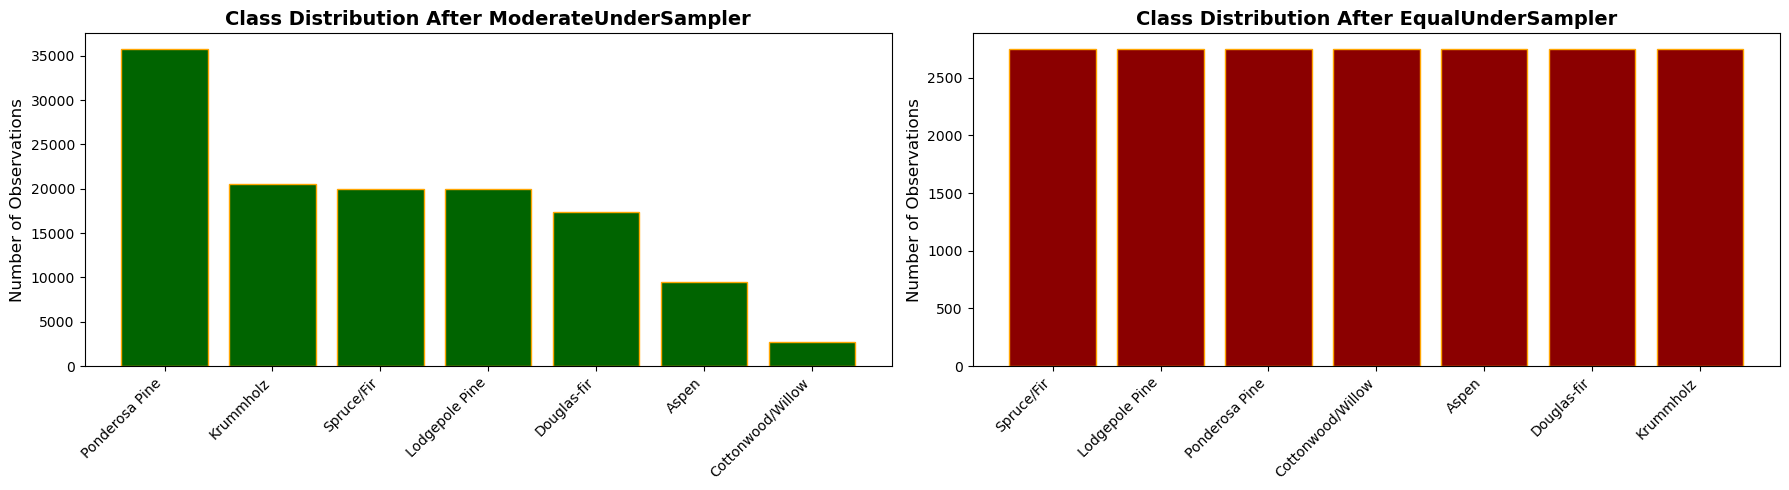

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(pd.Series(y_moderate_undersample).map(covertype_class).value_counts().index,
            pd.Series(y_moderate_undersample).map(covertype_class).value_counts().values,
            color='darkgreen', edgecolor='orange')
axes[0].set_title('Class Distribution After ModerateUnderSampler', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Observations', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

axes[1].bar(pd.Series(y_equal_undersample).map(covertype_class).value_counts().index,
            pd.Series(y_equal_undersample).map(covertype_class).value_counts().values,
            color='darkred', edgecolor='orange')
axes[1].set_title('Class Distribution After EqualUnderSampler', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Observations', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
df_moderate_undersampled = pd.DataFrame(x_moderate_undersample, columns=X.columns)
df_moderate_undersampled['Cover_Type'] = y_moderate_undersample

df_equal_undersampled = pd.DataFrame(x_equal_undersample, columns=X.columns)
df_equal_undersampled['Cover_Type'] = y_equal_undersample

df_moderate_undersampled.to_parquet('../data/processed/moderate_undersampled.parquet', index=False)
df_equal_undersampled.to_parquet('../data/processed/equal_undersampled.parquet', index=False)

#### NEARMISS

In [40]:
from imblearn.under_sampling import NearMiss

moderate_nm = NearMiss(sampling_strategy=sampling_strategy)
x_moderate_nm, y_moderate_nm = moderate_nm.fit_resample(X,y)

equal_nm = NearMiss(sampling_strategy='all')
x_equal_nm, y_equal_nm = equal_nm.fit_resample(X,y)

print(f"Shape of the dataset after ModerateUnderSampler: {Counter(y_moderate_nm)}")
print(f"Shape of the dataset after EqualUnderSampler: {Counter(y_equal_nm)}")

Shape of the dataset after ModerateUnderSampler: Counter({3: 35754, 7: 20510, 1: 20000, 2: 20000, 6: 17367, 5: 9493, 4: 2747})
Shape of the dataset after EqualUnderSampler: Counter({1: 2747, 2: 2747, 3: 2747, 4: 2747, 5: 2747, 6: 2747, 7: 2747})


C:\Users\Iñigo Peña\AppData\Local\Temp\ipykernel_2404\4195006671.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\Iñigo Peña\AppData\Local\Temp\ipykernel_2404\4195006671.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


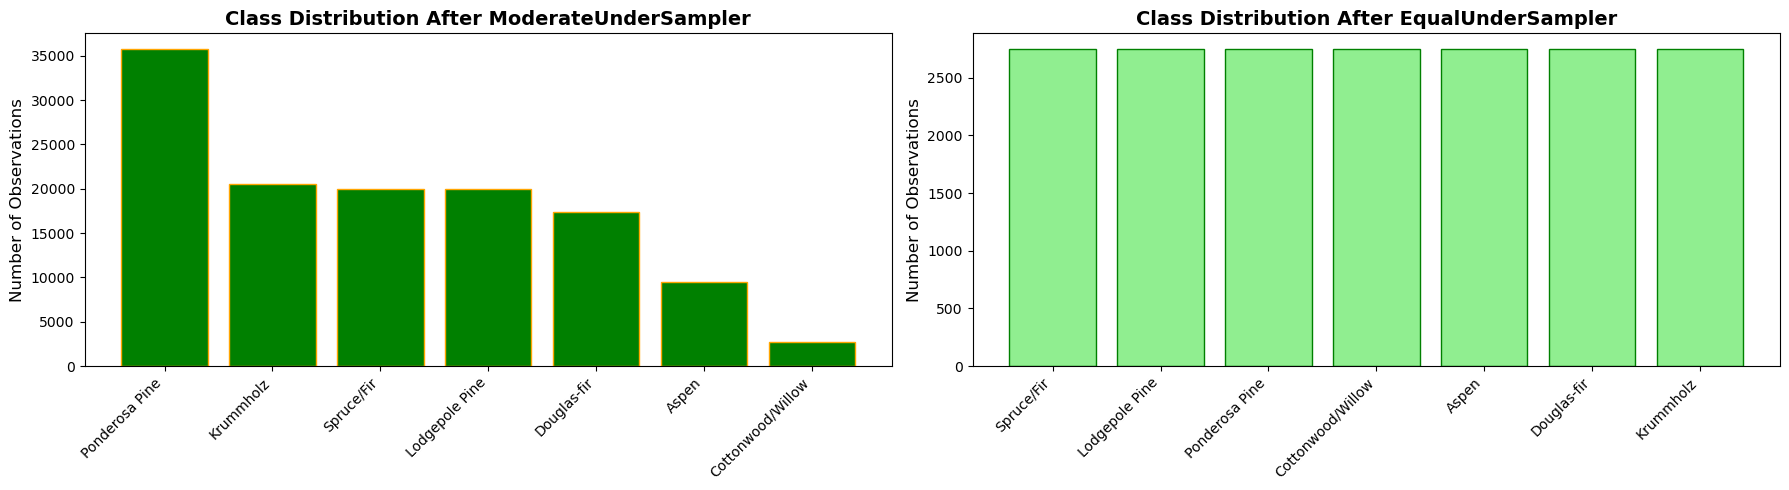

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(pd.Series(y_moderate_nm).map(covertype_class).value_counts().index,
            pd.Series(y_moderate_nm).map(covertype_class).value_counts().values,
            color='green', edgecolor='orange')
axes[0].set_title('Class Distribution After ModerateUnderSampler', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Observations', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

axes[1].bar(pd.Series(y_equal_nm).map(covertype_class).value_counts().index,
            pd.Series(y_equal_nm).map(covertype_class).value_counts().values,
            color='lightgreen', edgecolor='green')
axes[1].set_title('Class Distribution After EqualUnderSampler', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Observations', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
df_moderate_nm = pd.DataFrame(x_moderate_nm, columns=X.columns)
df_moderate_nm['Cover_Type'] = y_moderate_nm

df_equal_nm = pd.DataFrame(x_equal_nm, columns=X.columns)
df_equal_nm['Cover_Type'] = y_equal_nm

df_moderate_nm.to_parquet('../data/processed/NearMiss_moderate.parquet', index=False)
df_equal_nm.to_parquet('../data/processed/NearMiss_equal.parquet', index=False)

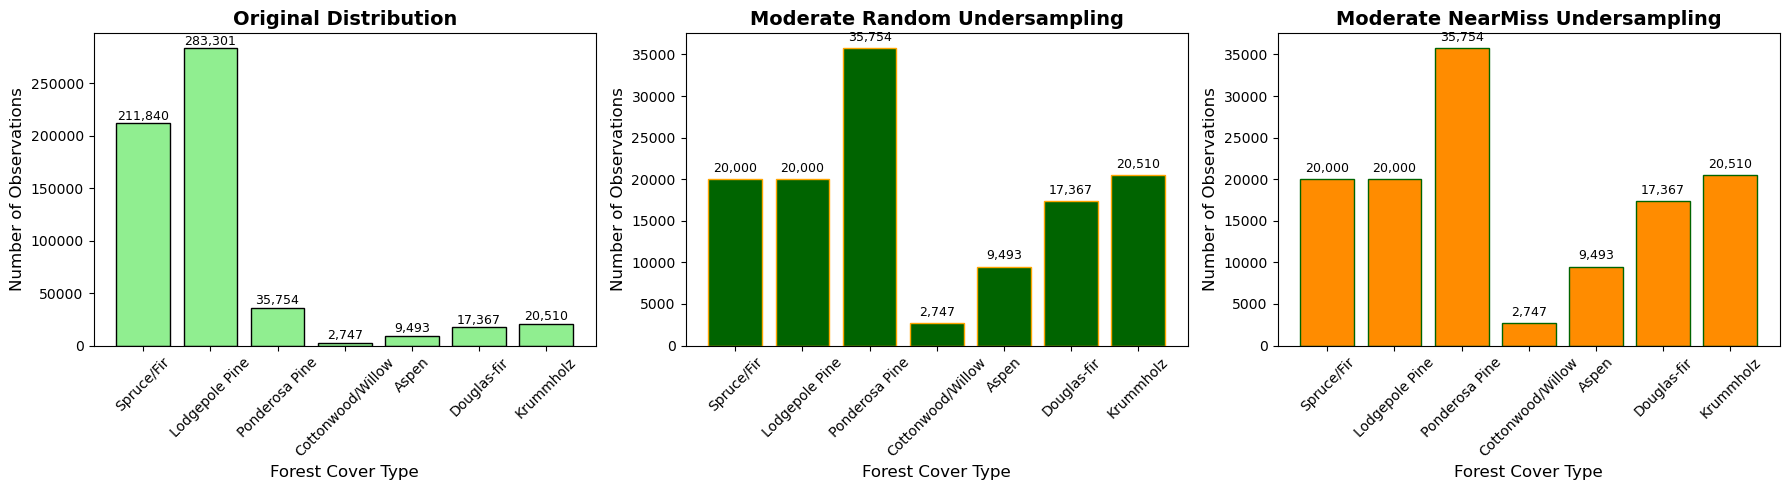

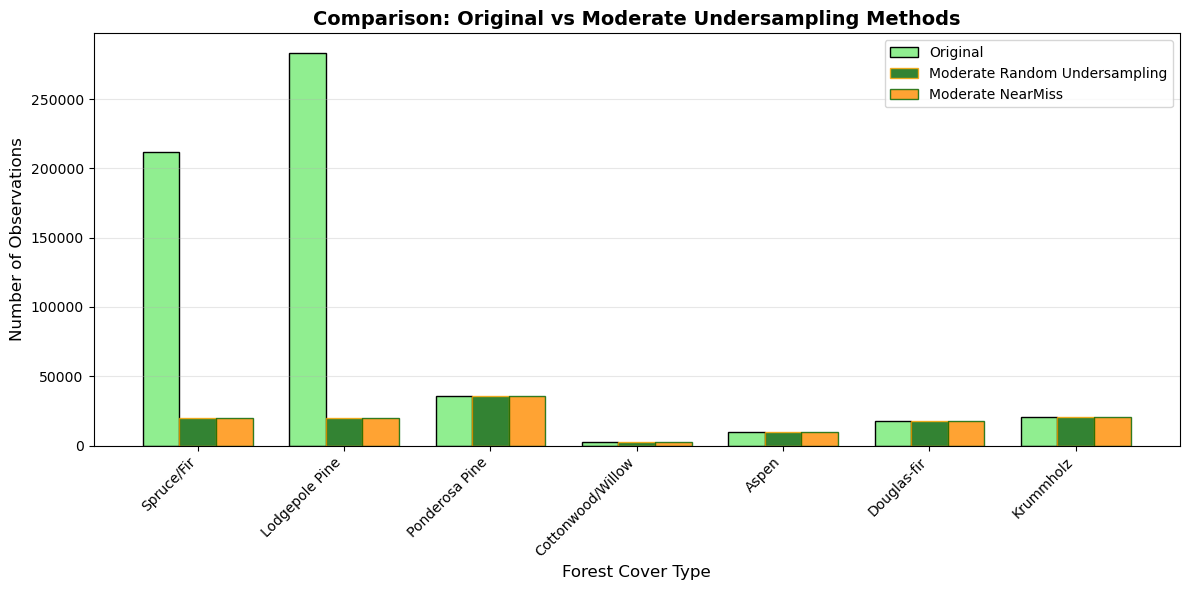

In [49]:
from collections import Counter

# Class counts for each approach
original_counts = Counter(y)
random_under_counts = Counter(y_moderate_undersample)
nearmiss_counts = Counter(y_moderate_nm)

comparison_data = []
for class_num in sorted(original_counts.keys()):
    comparison_data.append({
        'Class': covertype_class[class_num],
        'Original': original_counts[class_num],
        'Moderate Random Undersampling': random_under_counts[class_num],
        'Moderate NearMiss': nearmiss_counts[class_num]
    })

df_comparison = pd.DataFrame(comparison_data)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original distribution
axes[0].bar(df_comparison['Class'], df_comparison['Original'], color='lightgreen', edgecolor='black')
axes[0].set_title('Original Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Forest Cover Type', fontsize=12)
axes[0].set_ylabel('Number of Observations', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['Original']):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Moderate Random Undersampling distribution
axes[1].bar(df_comparison['Class'], df_comparison['Moderate Random Undersampling'], color='darkgreen', edgecolor='orange')
axes[1].set_title('Moderate Random Undersampling', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Forest Cover Type', fontsize=12)
axes[1].set_ylabel('Number of Observations', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['Moderate Random Undersampling']):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Moderate NearMiss distribution
axes[2].bar(df_comparison['Class'], df_comparison['Moderate NearMiss'], color='darkorange', edgecolor='darkgreen')
axes[2].set_title('Moderate NearMiss Undersampling', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Forest Cover Type', fontsize=12)
axes[2].set_ylabel('Number of Observations', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_comparison['Moderate NearMiss']):
    axes[2].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Grouped bar chart for direct comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_comparison['Class']))
width = 0.25

bars1 = ax.bar([i - width for i in x], df_comparison['Original'], width, 
               label='Original', color='lightgreen', edgecolor='black')
bars2 = ax.bar([i for i in x], df_comparison['Moderate Random Undersampling'], width,
               label='Moderate Random Undersampling', color='darkgreen', edgecolor='orange', alpha=0.8)
bars3 = ax.bar([i + width for i in x], df_comparison['Moderate NearMiss'], width,
               label='Moderate NearMiss', color='darkorange', edgecolor='darkgreen', alpha=0.8)

ax.set_xlabel('Forest Cover Type', fontsize=12)
ax.set_ylabel('Number of Observations', fontsize=12)
ax.set_title('Comparison: Original vs Moderate Undersampling Methods', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Class'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### 2. Cleaning Under-sampling

#### TOMEK'S LINKS

#### EDITED NEAREST NEIGHBORS

In [ ]:
from imblearn.under_sampling import EditedNearestNeighbours

enn = EditedNearestNeighbours()

mode_enn = EditedNearestNeighbours(kind_sel = 'mode')
x_mode_enn, y_mode_enn = mode_enn.fit_resample(X,y)

all_enn = EditedNearestNeighbours(kind_sel = 'all')
x_all_enn, y_all_enn = all_enn.fit_resample(X,y)

print(f"Shape of the dataset after 'mode' ENN: {Counter(y_mode_enn)}")
print(f"Shape of the dataset after 'all' ENN: {Counter(y_all_enn)}")

KeyboardInterrupt: 